In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
import re
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize tqdm with pandas
tqdm.pandas()


In [2]:
train_neg = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\train_Arabic_tweets_negative_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)

train_neg.head()

,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم بالزايد 😭
0,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
1,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
2,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
3,neg,الدودو جايه تكمل علي 💔
4,neg,أحببته حتى أقنعنى إن ما فات من العمر كان إنتظا...


In [3]:
train_pos = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\train_Arabic_tweets_positive_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
train_pos.head()

,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لله، لا تبحثوا فينا عن قوة، إننا مكسورون، القوة التي…
0,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
1,pos,من الخير نفسه 💛
2,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
3,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
4,pos,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...


In [4]:
test_neg = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\test_Arabic_tweets_negative_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
test_neg.head()

,neg,حتى الايتونز خربتوه مو صاحين انتو؟؟ 😭
0,neg,واحد تبع النظام السوري يقول أن المخابرات السور...
1,neg,الى متى التعامل السئ للخادمات وعدم احترامهم وك...
2,neg,رايح جاي ي طحلبي 🐸 #الهلال_الاهلي
3,neg,تتمغط ومعها سداع 😫
4,neg,اذا ما كان ألطف كوبل مر عليكم 😭😭💛💛 حظ جانيت بس...


In [5]:
test_pos = pd.read_csv(
    r"C:\Users\mrtat\Downloads\DL task\dataset\test_Arabic_tweets_positive_20190413.tsv",
    sep='\t',
    encoding='utf-8'
)
test_pos.head()

,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله 💙 زوران كان بيسلم المباراة بعد تبديل كارييو بإنتظار الإتحاد بكرة يارب يار…
0,pos,صباحك خيرات ومسرات 🌸
1,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
2,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
3,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...
4,pos,اجيال القووه والصمود والتحدي اجيال المستقبل وا...


In [6]:
# Name columns
train_pos.columns = [ 'label', 'tweet']
train_neg.columns = [ 'label', 'tweet']
test_pos.columns  = [ 'label', 'tweet']
test_neg.columns  = [ 'label', 'tweet']

In [7]:
# Merge datasets
train_df = pd.concat([train_pos, train_neg], ignore_index=True)
test_df  = pd.concat([test_pos, test_neg], ignore_index=True)


In [8]:
train_df.head()

,label,tweet
0,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
1,pos,من الخير نفسه 💛
2,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
3,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
4,pos,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...


In [9]:
test_df.head()

,label,tweet
0,pos,صباحك خيرات ومسرات 🌸
1,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
2,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
3,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...
4,pos,اجيال القووه والصمود والتحدي اجيال المستقبل وا...


In [10]:
print(train_df.shape, test_df.shape)

(45273, 2) (11518, 2)


In [11]:
train_df.isnull().sum()

label    0
tweet    0
dtype: int64

In [12]:
test_df.isnull().sum()

label    0
tweet    0
dtype: int64

In [13]:
mapping = { 'pos': 1, 'neg': 0 }
train_df['label'] = train_df['label'].map(mapping)
test_df['label']  = test_df['label'].map(mapping)

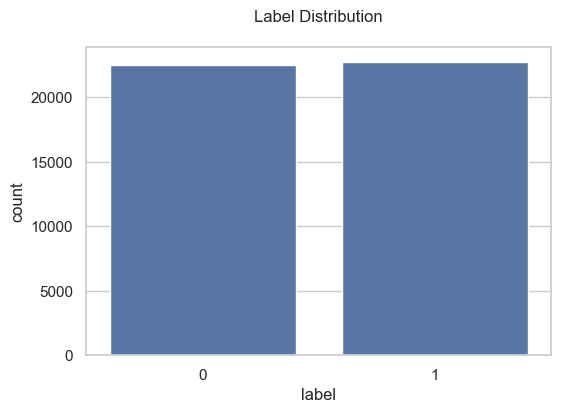

In [14]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df)
plt.title('Label Distribution\n')
plt.show()

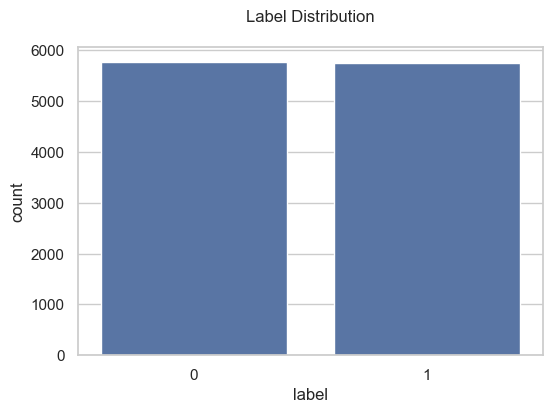

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=test_df)
plt.title('Label Distribution\n')
plt.show()

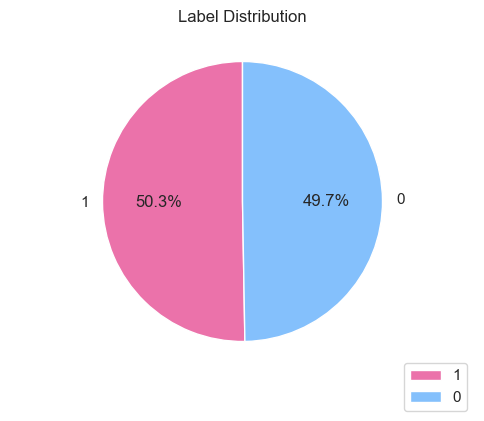

In [16]:
counts = train_df['label'].value_counts()
counts.plot(
    kind='pie',
    figsize=(6, 4),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90°   
    colors=["#eb72aa","#84c0fc"],  # Custom colors for the pie chart    
)

plt.title('Label Distribution\n')
plt.axis('equal')  # Sets the pie chart to look like a circle.
plt.legend(labels=counts.index, bbox_to_anchor=(1, 0))
plt.ylabel('')  # Hide y-label
plt.show()

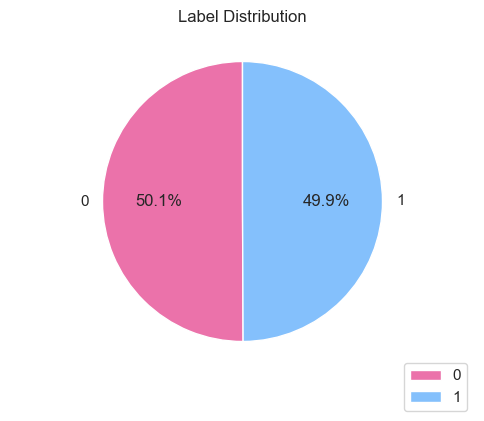

In [17]:
counts = test_df['label'].value_counts()
counts.plot(
    kind='pie',
    figsize=(6, 4),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90°   
    colors=["#eb72aa","#84c0fc"],  # Custom colors for the pie chart    
)

plt.title('Label Distribution\n')
plt.axis('equal')  # Sets the pie chart to look like a circle.
plt.legend(labels=counts.index, bbox_to_anchor=(1, 0))
plt.ylabel('')  # Hide y-label
plt.show()

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mrtat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
arabic_StopWords = stopwords.words("arabic")
english_StopWords = stopwords.words("english")

In [20]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'http\S+|www.\S+', '', text)  # remove links
    text = re.sub(r'@\w+|#\w+', '', text)  # mentions & hashtags
    text = re.sub(r'[0-9٠-٩]+', '', text)  # remove digits /d from 0-9 
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)  # remove non-Arabic characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    text = emoji.replace_emoji(text, replace='')
    # remove stopwords
    text = " ".join([w for w in text.split() if w not in arabic_StopWords and w not in english_StopWords])
    return text

In [21]:
# apply cleaning function to tweets
train_df['tweet'] = train_df['tweet'].apply(lambda x: clean_text(x))
test_df['tweet']  = test_df['tweet'].apply(lambda x: clean_text(x))

In [22]:
train_df.head()

,label,tweet
0,1,وفي النهاية يبقىٰ معك آحدإلا رأىٰ الجمال روحك ...
1,1,الخير نفسه
2,1,عالي الهمه ترضى بغير القمه مجرد ساعات لاستعادة...
3,1,الشيء الوحيد وصلوا للعالمية المسيار ترى كانوا ...
4,1,لاتحسبونا نسينا يالطواقي ولانبيكم توقفون معنا ...


In [23]:
# features (tweets)
X_train = train_df['tweet']
X_test  = test_df['tweet']

In [ ]:
#labels
y_train = train_df['label'].astype(int)
y_test  = test_df['label'].astype(int)

In [25]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True,
                                    tokenizer=None,
                                    stop_words=None,
                                    ngram_range=(1, 1),
                                    max_features=10000, # Limit to top 10k words to reduce noise
                                    binary=False)

# Transform the text data into a document-term matrix
X_tr = tfidf_vectorizer.fit_transform(X_train)
X_te = tfidf_vectorizer.transform(X_test)

In [26]:
vocab = tfidf_vectorizer.get_feature_names_out()
vocab

array(['آجمل', 'آحلى', 'آخر', ..., 'ھادئ', 'یبقی', 'یوم'],
      shape=(10000,), dtype=object)

In [27]:
X_train2 = pd.DataFrame(X_tr.toarray(), columns=vocab)

X_train2.head()

,آجمل,آحلى,آخر,آخره,آداء,آدم,آرمييز,آسف,آسيا,آغثني,...,ڪل,ڪلما,ڪن,ګنت,گل,گم,گن,ھادئ,یبقی,یوم
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
from sklearn.naive_bayes import MultinomialNB # Changed from GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
clf = MultinomialNB()

# Train the model using the Sparse Matrix (X_tr) directly
clf.fit(X_tr, y_train)

# Predict on test data
y_pred = clf.predict(X_te)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7476124327140129

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      5767
           1       0.75      0.74      0.74      5751

    accuracy                           0.75     11518
   macro avg       0.75      0.75      0.75     11518
weighted avg       0.75      0.75      0.75     11518

